In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hassan06/nslkdd")

print("Path to dataset files:", path)

c:\Users\sheen\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 13.9M/13.9M [00:03<00:00, 4.14MB/s]

Extracting files...


Path to dataset files: C:\Users\sheen\.cache\kagglehub\datasets\hassan06\nslkdd\versions\1


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE
import joblib



In [4]:
# Update paths to your local dataset files
train_file = r"C:\Users\sheen\.cache\kagglehub\datasets\hassan06\nslkdd\versions\1\KDDTrain+.txt"
test_file  = r"C:\Users\sheen\.cache\kagglehub\datasets\hassan06\nslkdd\versions\1\KDDTest+.txt"

# NSL-KDD has 43 columns (42 features + 1 difficulty score)
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

df_train = pd.read_csv(train_file, names=col_names)
df_test  = pd.read_csv(test_file, names=col_names)

# Combine for preprocessing
df = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)
df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
# Drop unused column
df = df.drop(columns=["difficulty"])

# Binary labels: normal vs attack
df["label"] = df["label"].apply(lambda x: "normal" if x == "normal" else "attack")

X = df.drop(columns=["label"])
y = df["label"]

# Identify categorical & numeric columns
categorical = ["protocol_type", "service", "flag"]
numeric = [col for col in X.columns if col not in categorical]

# Preprocessor: OneHot for categoricals + Scaling for numeric
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", StandardScaler(), numeric)
    ]
)


In [7]:
# Apply preprocessing first (OneHot + Scaling)
X_encoded = preprocessor.fit_transform(X)

# Train/Test split on the already encoded data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# Apply SMOTE only on numeric data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train_res.shape)
print("Normal/Attack ratio:", y_train_res.value_counts().to_dict())


Training set size: (118813, 122)
Testing set size: (29704, 122)
After SMOTE: (123286, 122)
Normal/Attack ratio: {'attack': 61643, 'normal': 61643}


In [8]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NaiveBayes": GaussianNB(),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}



🔹 LogisticRegression Results:
              precision    recall  f1-score   support

      attack       0.96      0.95      0.96     14293
      normal       0.95      0.97      0.96     15411

    accuracy                           0.96     29704
   macro avg       0.96      0.96      0.96     29704
weighted avg       0.96      0.96      0.96     29704



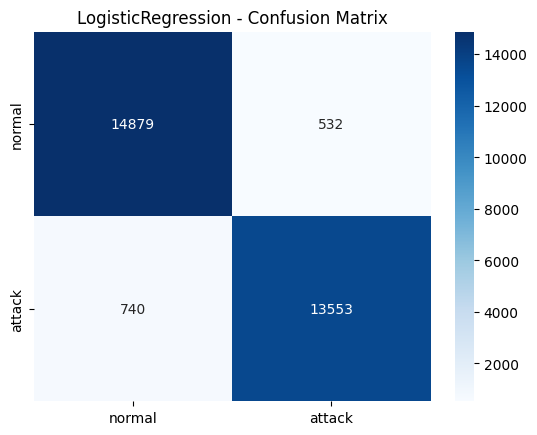


🔹 RandomForest Results:
              precision    recall  f1-score   support

      attack       1.00      0.99      1.00     14293
      normal       1.00      1.00      1.00     15411

    accuracy                           1.00     29704
   macro avg       1.00      1.00      1.00     29704
weighted avg       1.00      1.00      1.00     29704



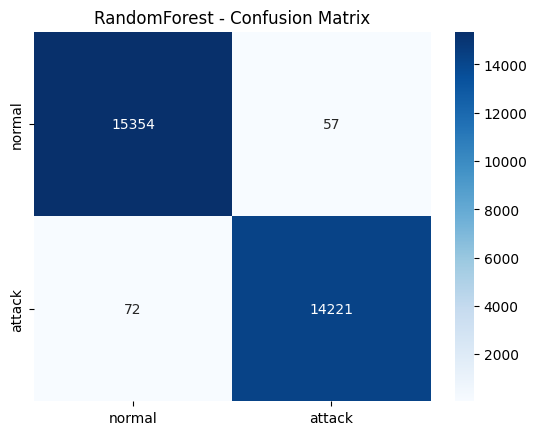


🔹 GradientBoosting Results:
              precision    recall  f1-score   support

      attack       0.99      0.99      0.99     14293
      normal       0.99      0.99      0.99     15411

    accuracy                           0.99     29704
   macro avg       0.99      0.99      0.99     29704
weighted avg       0.99      0.99      0.99     29704



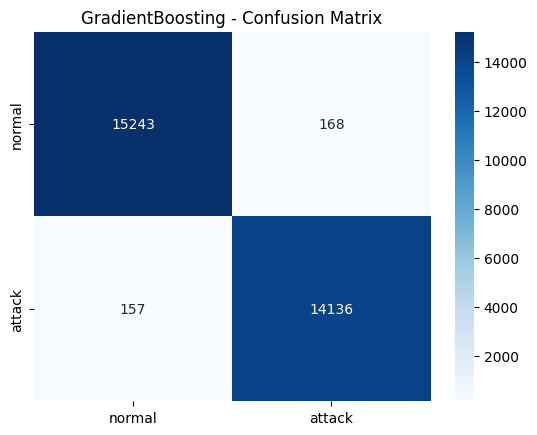


🔹 SVM Results:
              precision    recall  f1-score   support

      attack       0.98      0.99      0.98     14293
      normal       0.99      0.98      0.99     15411

    accuracy                           0.99     29704
   macro avg       0.98      0.99      0.99     29704
weighted avg       0.99      0.99      0.99     29704



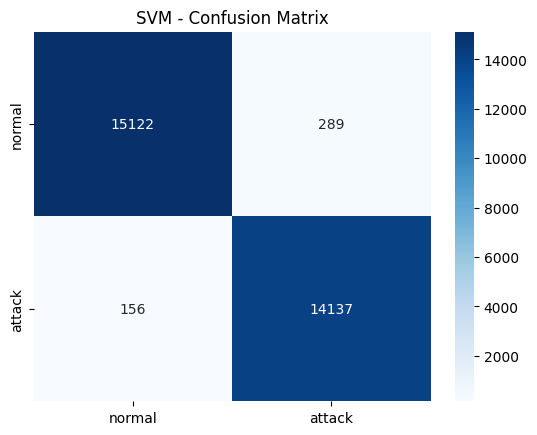


🔹 KNN Results:
              precision    recall  f1-score   support

      attack       0.99      0.99      0.99     14293
      normal       0.99      0.99      0.99     15411

    accuracy                           0.99     29704
   macro avg       0.99      0.99      0.99     29704
weighted avg       0.99      0.99      0.99     29704



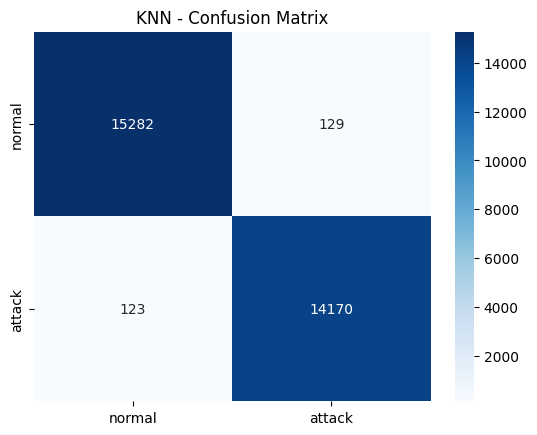


🔹 NaiveBayes Results:
              precision    recall  f1-score   support

      attack       0.99      0.63      0.77     14293
      normal       0.75      1.00      0.85     15411

    accuracy                           0.82     29704
   macro avg       0.87      0.81      0.81     29704
weighted avg       0.86      0.82      0.81     29704



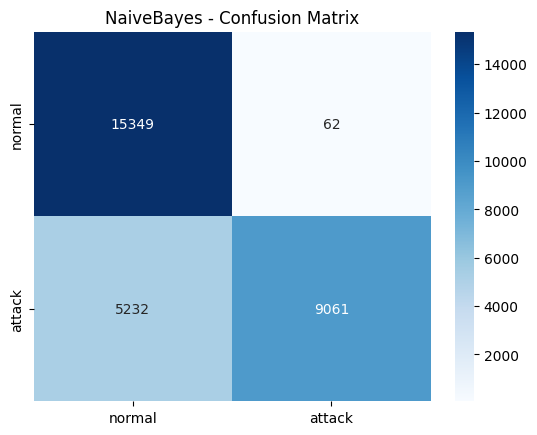


🔹 MLP Results:
              precision    recall  f1-score   support

      attack       0.99      0.99      0.99     14293
      normal       0.99      0.99      0.99     15411

    accuracy                           0.99     29704
   macro avg       0.99      0.99      0.99     29704
weighted avg       0.99      0.99      0.99     29704



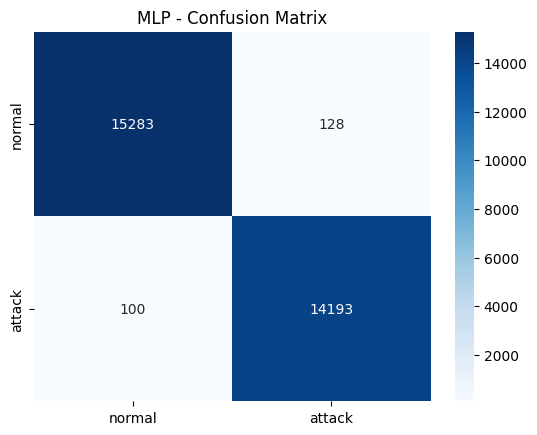


✅ Accuracy summary: {'LogisticRegression': 0.9571774845138702, 'RandomForest': 0.9956571505521142, 'GradientBoosting': 0.9890587126312954, 'SVM': 0.9850188526797737, 'KNN': 0.9915162941018044, 'NaiveBayes': 0.8217748451387018, 'MLP': 0.9923242660921088}


In [10]:
results = {}

for name, model in models.items():
    # Train model directly on resampled numeric data
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n🔹 {name} Results:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred, labels=["normal", "attack"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["normal", "attack"], yticklabels=["normal", "attack"])
    plt.title(f"{name} - Confusion Matrix")
    plt.show()
    
    # Save trained model
    joblib.dump(model, f"{name}_nslkdd.joblib")

print("\n✅ Accuracy summary:", results)


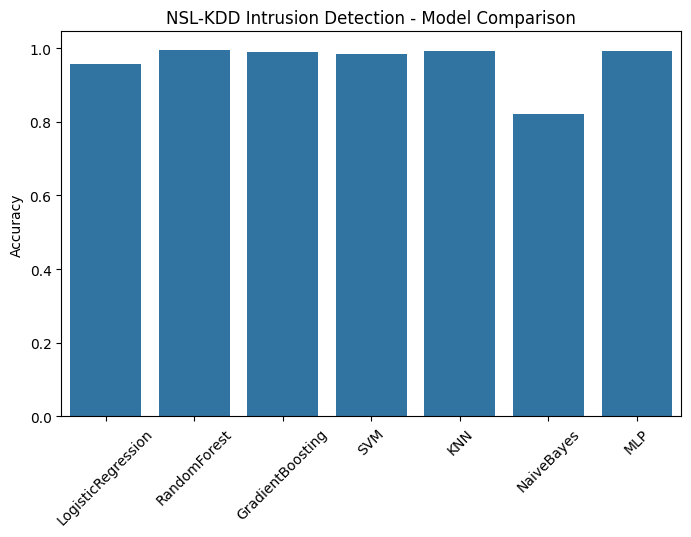

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("NSL-KDD Intrusion Detection - Model Comparison")
plt.show()
